In [1]:
import sys
sys.path.append("../../src")

import numpy as np
from numba import njit
from scipy.stats import ortho_group
from tqdm import tqdm
import matplotlib.pyplot as plt

from python_utils.visualization_utils import display_matrix, plot_bss_comparison, subplot_1D_signals
from bss.bss_utils import generate_uncorrelated_uniform_sources, generate_correlated_copula_sources, addWGN, ProjectColstoSimplex
from bss.LDMIBSS import LDMIBSS

# Generate Sources and Mix Them (10 by 5 case)

In [2]:
# np.random.seed(400)
seed = np.random.randint(5000000)
np.random.seed(seed)
print("seed is ", seed)
N = 10000
NumberofSources = 5
NumberofMixtures = NumberofSources + 5

S = generate_uncorrelated_uniform_sources(NumberofSources, N, min_val = -4, max_val = 4)
S = ProjectColstoSimplex(S)

print("The following is the correlation matrix of sources")
display_matrix(np.corrcoef(S))

# # Generate Mxr random mixing from i.i.d N(0,1)
A = np.random.randn(NumberofMixtures, NumberofSources) # Random Gaussian mixing matrix
# A = ortho_group.rvs(dim=NumberofSources) # Random orthogonal mixing matrix
X_noNoise = np.dot(A, S)


SNR = 30
X = addWGN(X_noNoise, SNR)

SNRinp = 10 * np.log10(
    np.sum(np.mean(X_noNoise ** 2, axis=1))
    / np.sum(np.mean((X_noNoise - X)**2, axis=1))
)
print("The following is the mixture matrix A")
display_matrix(A)
print("Input SNR is : {}".format(SNRinp))
S.var(1), X.var(1)

seed is  4779497
The following is the correlation matrix of sources


<IPython.core.display.Math object>

The following is the mixture matrix A


<IPython.core.display.Math object>

Input SNR is : 29.963202384906516


(array([0.12317959, 0.12267587, 0.12566752, 0.1253112 , 0.12548127]),
 array([0.54035536, 0.80618201, 0.35710841, 1.15924635, 0.30842013,
        0.17444788, 1.48452505, 0.28322163, 1.04154928, 0.40785275]))

# Hyperparameters

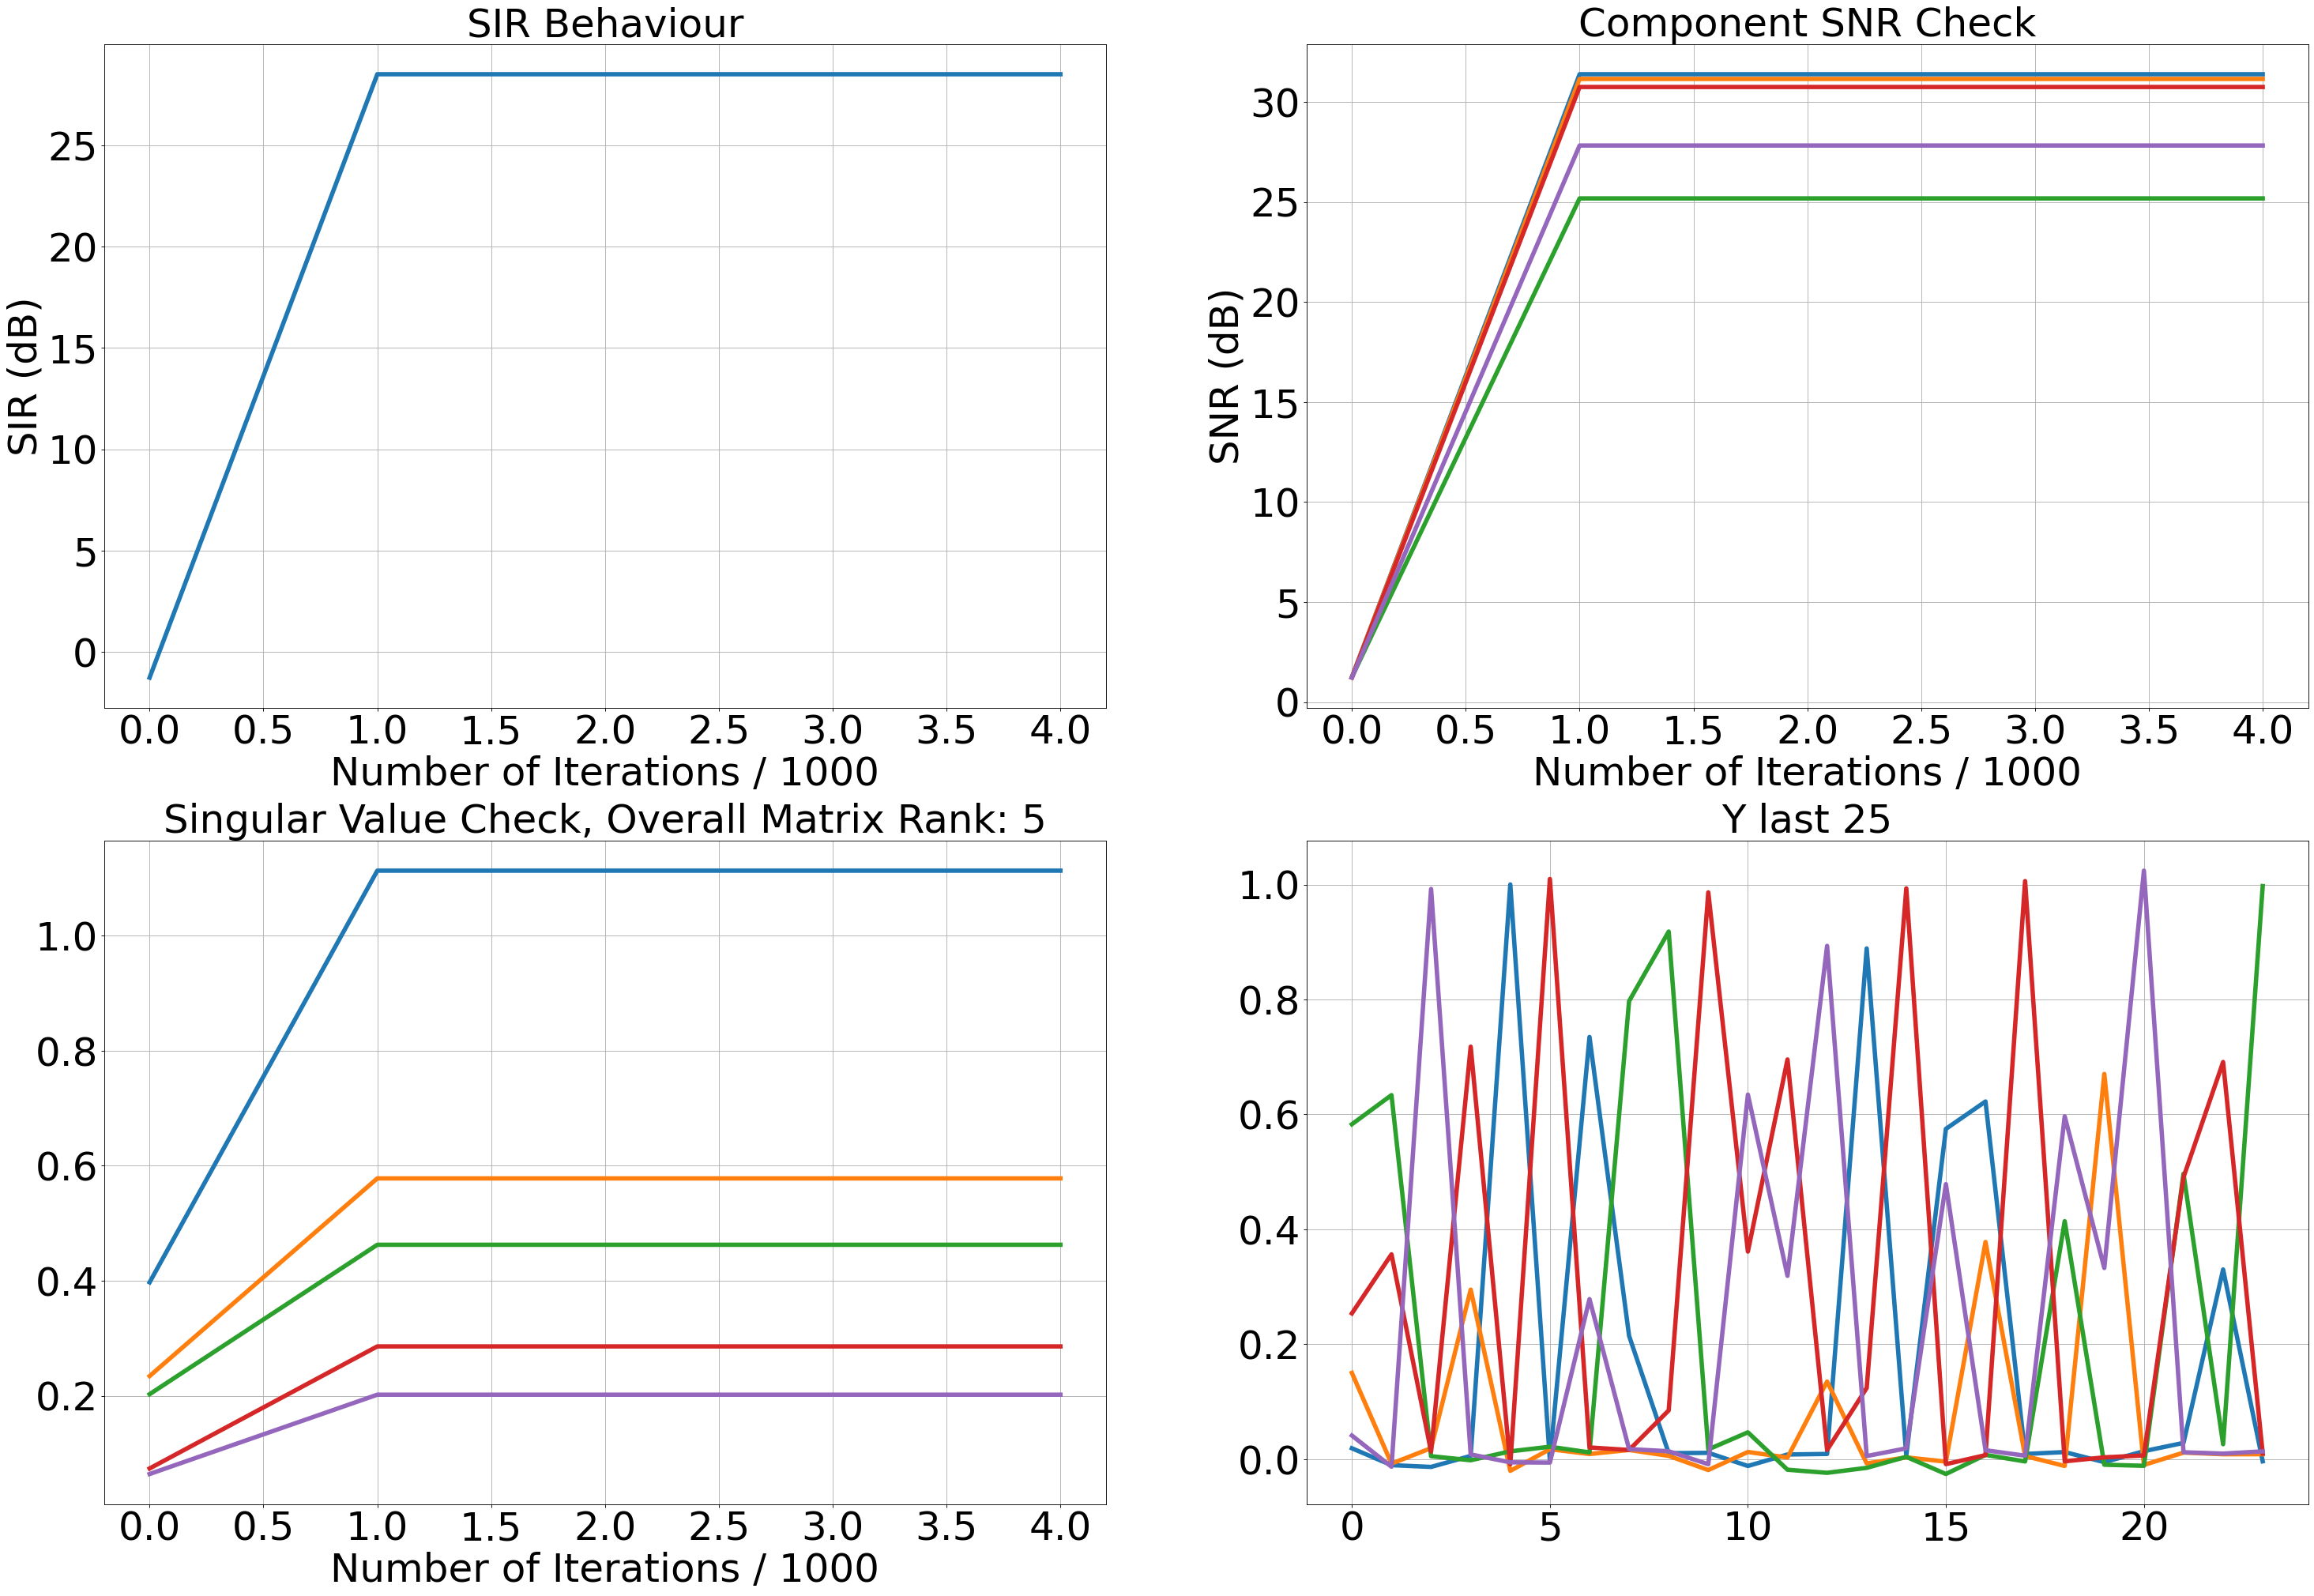

100%|██████████| 5000/5000 [00:41<00:00, 119.33it/s]


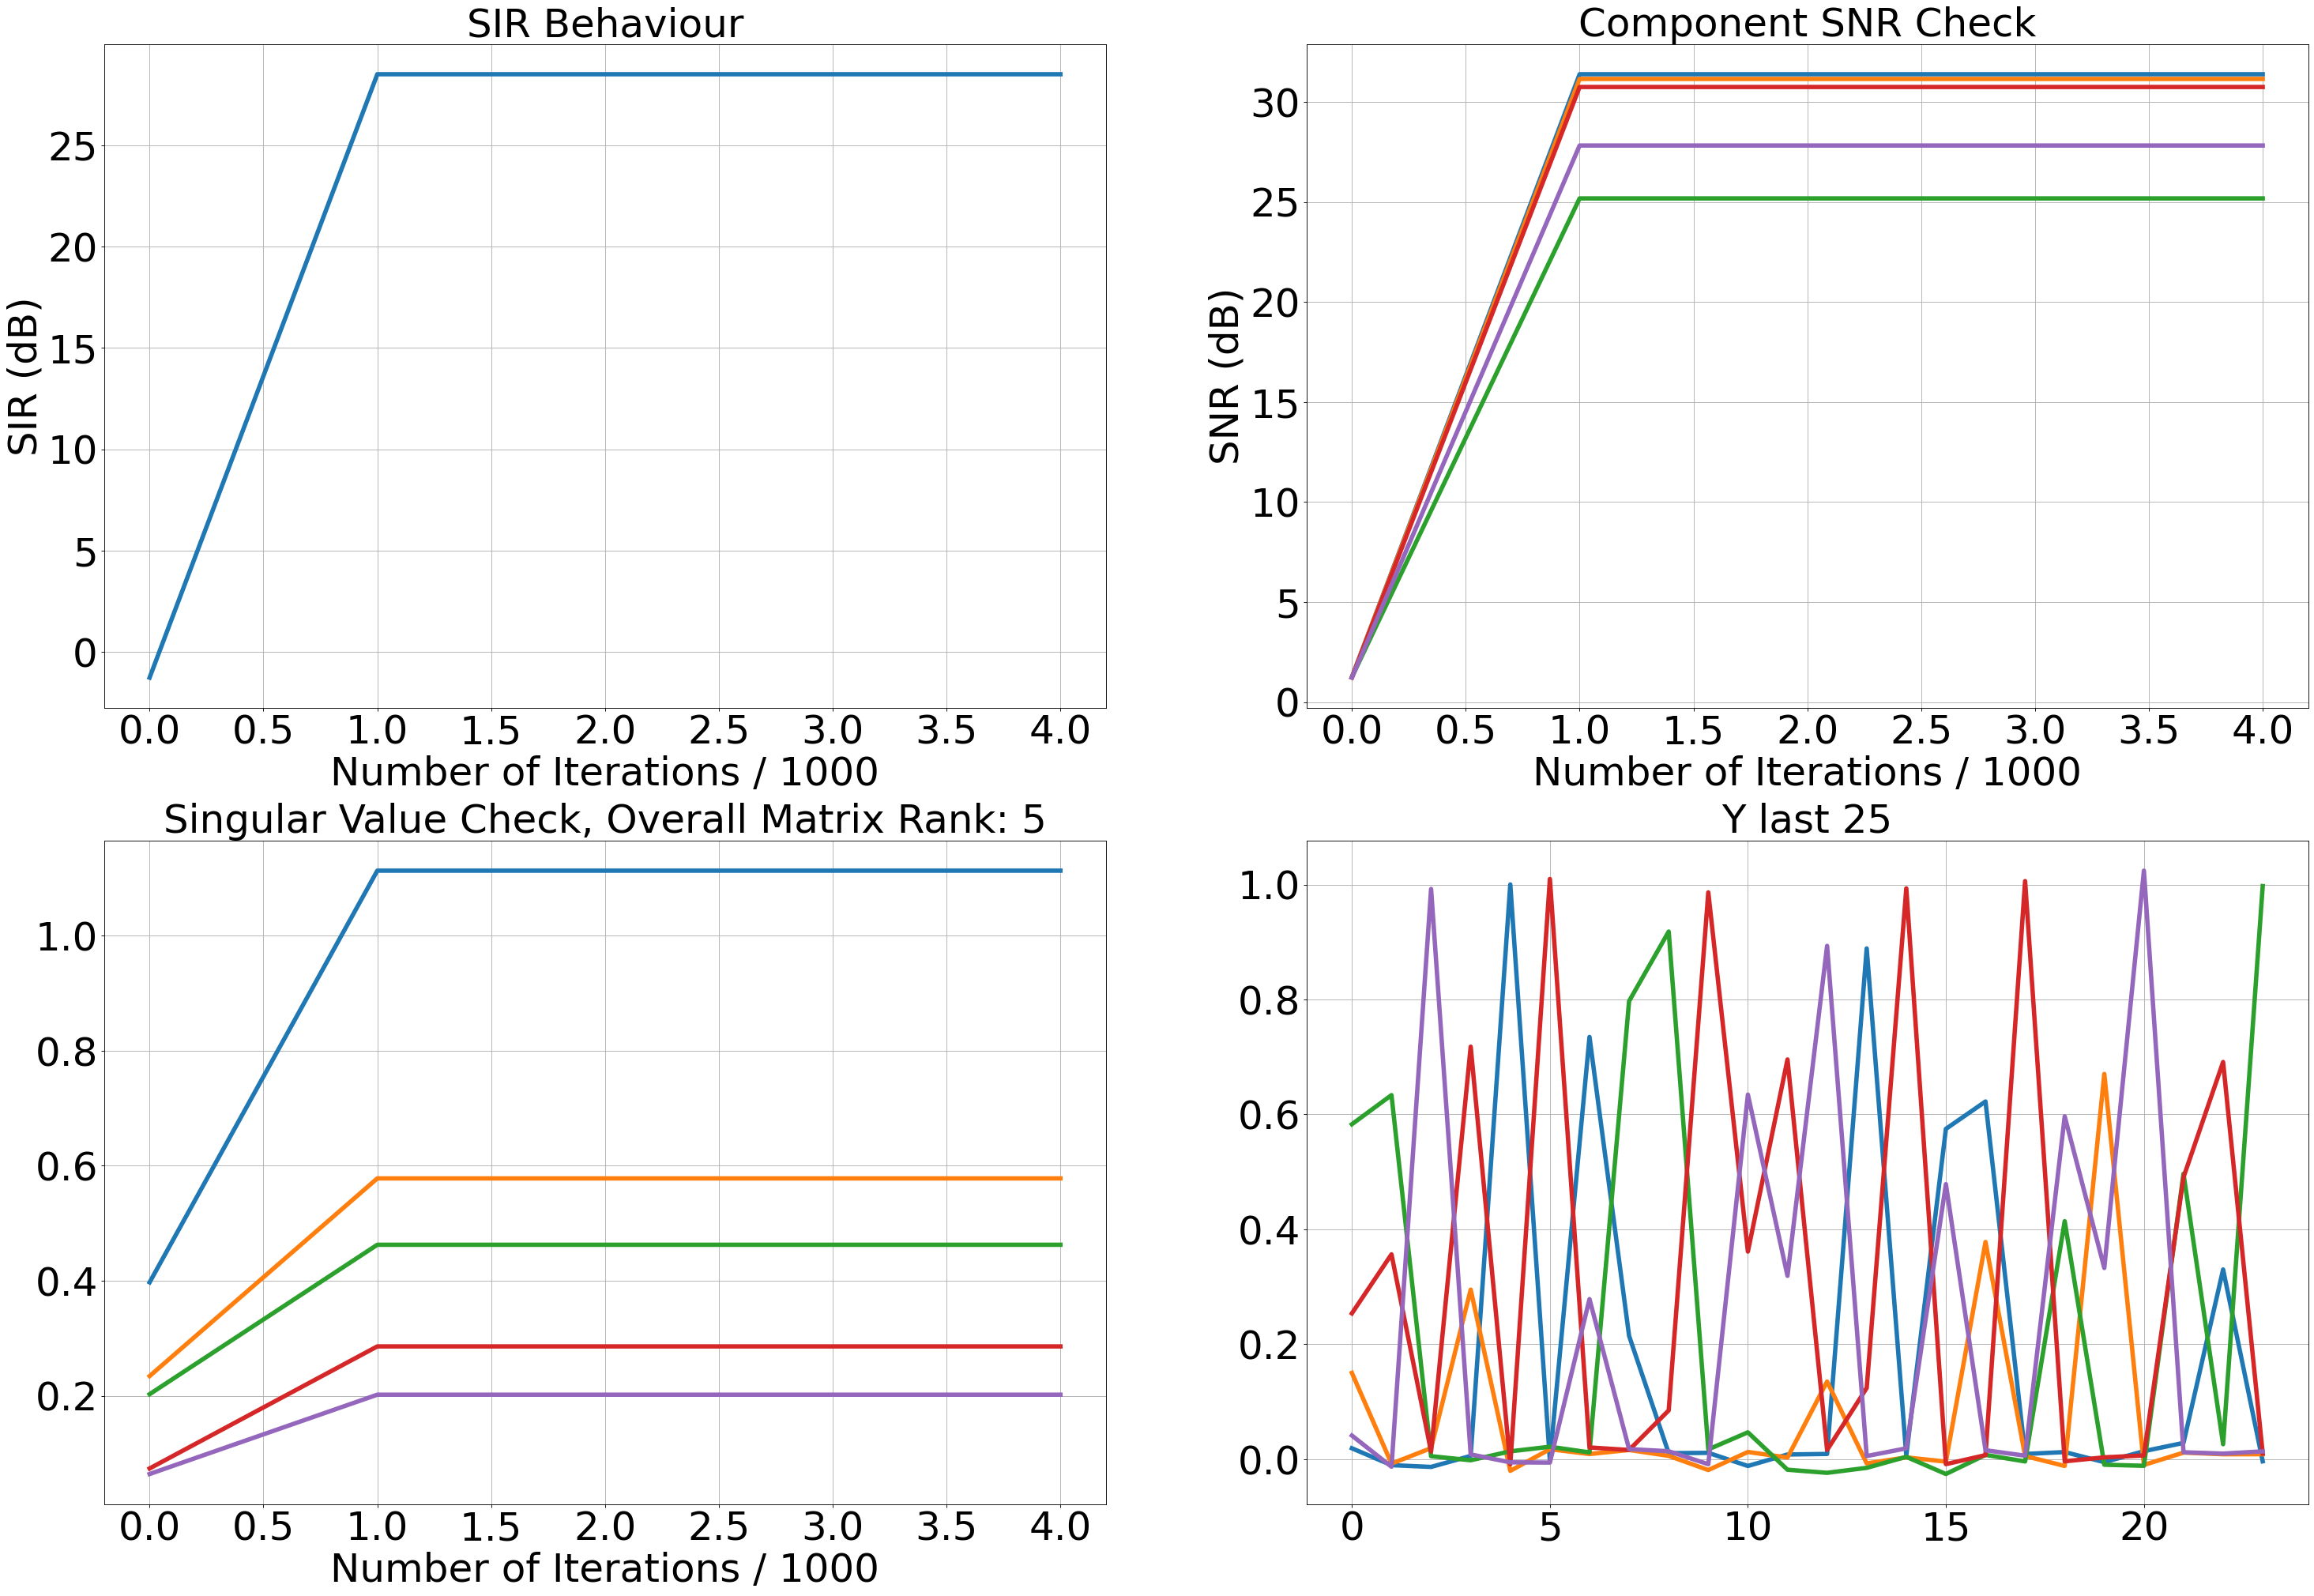

In [3]:
hyperparam_dict = {
                "n_sources" :  NumberofSources,
                "presumed_domain" : "simplex",
                "method" : "correlation",
                ### Optimization parameters and Learning rates 
                "mu_y_start" : 100,
                "mu_y_rule" : "exponential_decay",
                "epsilon" : 1e-3,
                ### Ground truth source vectors. This part is only for debugging.
                "Sgt" : S,
                "debug_iteration_point" : 1000,
                "plot_debug_during_training" : True,
}
model = LDMIBSS(**hyperparam_dict)
model.fit(X, regularize_W = False)

In [4]:
Y_ = model.predict(X)
Y_ = model.signed_and_permutation_corrected_sources(S, Y_) # Find sign and permutation ambiguity
coef_ = ((Y_ * S).sum(axis=1) / (Y_ * Y_).sum(axis=1)).reshape(-1, 1) # Find if the extracted signals need some amplification! The networks learned weight may need amplification due to lateral connections during the neural dynamics!
Y_ = coef_ * Y_

print("Signal-to-Interference-and-Noise-Ratio (SINR): {}".format(model.ComputeSINR(S, Y_)))
print("Component Signal-to-Noise-Ratio (SNR) Values : {}\n".format(model.ComputeSNR(S, Y_)))

Signal-to-Interference-and-Noise-Ratio (SINR): 28.507293625631377
Component Signal-to-Noise-Ratio (SNR) Values : [31.38087429 31.14617307 25.17468911 30.7434216  27.81835161]



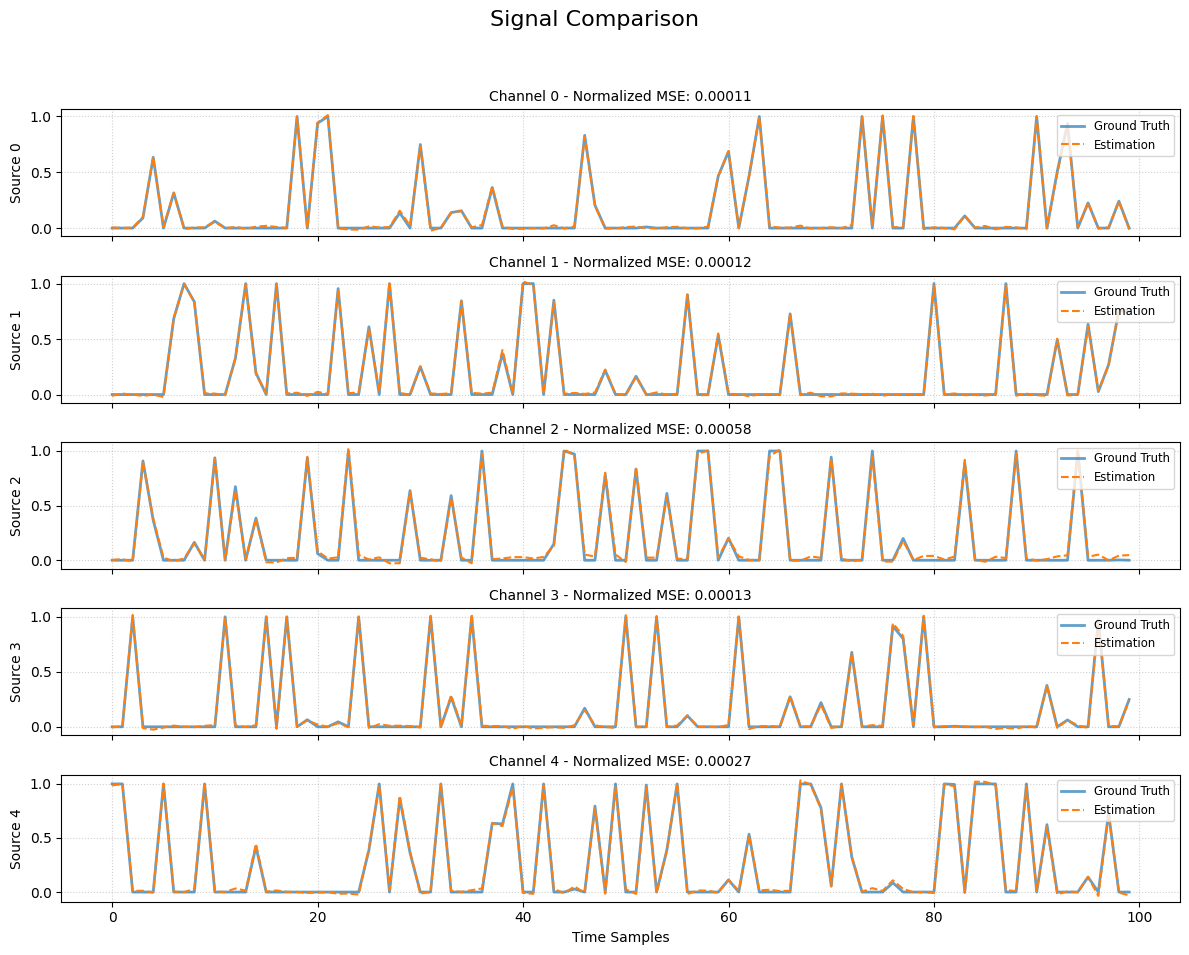

In [5]:
plot_bss_comparison(S[:, 0:100], Y_[:, 0:100])